# Tutorial 6 — How precise is this measurement?

## 1. Problem / context

Quality reports a mean plate thickness from `sensor_thickness.csv`. A single number is not enough: process engineering needs an interval for the **population mean** $\mu$, and a separate interval for the **proportion** of plates that exceed a thickness limit.

Brooks Chapter 6 is the theory: estimator versus estimate, standard error, coverage, the $t$ interval, and why the Wilson interval is the practical default for a proportion. This tutorial is the Python and interpretation layer.

The observational unit is one plate. The target population is plates produced under the sampled operating conditions. We treat the 180 records as a sample, not as the entire future process.

## 2. What we will compute

- An **estimator** $\hat\theta$ is a random procedure; an **estimate** is the number we obtained. **Bias** is $E[\hat\theta]-\theta$. Bias matters, but in this course the main job is to quantify sampling precision under a credible model.
- For a mean with unknown $\sigma$, the 95% **$t$ interval** is

$$
\bar x\pm t_{n-1,\,0.975}\,\frac{s}{\sqrt n}.
$$

  A $z$ interval that uses a known population $\sigma$ is appropriate only when that $\sigma$ is genuinely known. A large sample is not a reason to pretend $\sigma$ is known.
- **Coverage**: 95% describes the long-run success rate of the *procedure*. After one sample is observed, the realised interval either covers $\mu$ or it does not; we do not assign probability 0.95 to the parameter.
- Interval **width** shrinks with larger $n$ and grows with $s$ and with the confidence level. More data do not repair bias, dependence, or a non-representative sample.
- For a proportion, the **Wilson interval** is the practical default. The **Wald** interval $\hat p\pm z\sqrt{\hat p(1-\hat p)/n}$ is shown only to explain why it can fail near 0 or 1 or with small $n$.
- A short **bootstrap percentile** interval is a computational check. Resampling the observed sample approximates sampling variation; it does not create new information.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t, norm, bootstrap
from statsmodels.stats.proportion import proportion_confint

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())

x = pd.read_csv(DATA / "sensor_thickness.csv")["thickness_um"].to_numpy()
n = x.size
xbar = x.mean()
s = x.std(ddof=1)
se = s / np.sqrt(n)
print(f"n = {n}")
print(f"estimate  xbar = {xbar:.3f} µm")
print(f"sample SD s    = {s:.3f} µm")
print(f"SE(Xbar)       = {se:.3f} µm")


n = 180
estimate  xbar = 250.830 µm
sample SD s    = 4.809 µm
SE(Xbar)       = 0.358 µm


Build the $t$ interval from its pieces, then verify with SciPy. `t.interval` uses `scale` as the **standard error**, not as $s$.


In [2]:
df_t = n - 1
t_crit = t.ppf(0.975, df_t)
moe = t_crit * se
ci_lo, ci_hi = xbar - moe, xbar + moe
ci_scipy = t.interval(0.95, df_t, loc=xbar, scale=se)
print(f"t_crit(df={df_t}) = {t_crit:.3f}")
print(f"margin of error   = {moe:.3f} µm")
print(f"95% t-interval    = [{ci_lo:.3f}, {ci_hi:.3f}] µm")
print("SciPy check       =", tuple(np.round(ci_scipy, 3)))


t_crit(df=179) = 1.973
margin of error   = 0.707 µm
95% t-interval    = [250.123, 251.538] µm
SciPy check       = (np.float64(250.123), np.float64(251.538))


Pause: is this interval a range for **individual plates**, or for the **mean** of the process?

A $z$ interval would replace $t_{\mathrm{crit}}$ by $z_{0.975}$ and $s$ by a **known** $\sigma$. We do not have a known population SD here, so the $t$ interval is the working method.

### Coverage of the $t$ procedure

Keep $\mu$ fixed. Draw many independent samples from a known normal model and count how often the interval covers $\mu$. The parameter does not move; the interval does.


In [3]:
rng = np.random.default_rng(2026)
mu_true, sigma_true = 250.0, 4.2
n_sim, n_rep = 20, 20_000
samples = rng.normal(mu_true, sigma_true, size=(n_rep, n_sim))
means = samples.mean(axis=1)
sds = samples.std(axis=1, ddof=1)
se_sim = sds / np.sqrt(n_sim)
t_sim = t.ppf(0.975, n_sim - 1)
lo = means - t_sim * se_sim
hi = means + t_sim * se_sim
covers = (lo <= mu_true) & (hi >= mu_true)
print(f"estimated coverage = {covers.mean():.3f}")
print(f"mean width         = {(hi - lo).mean():.2f} µm")


estimated coverage = 0.951
mean width         = 3.88 µm


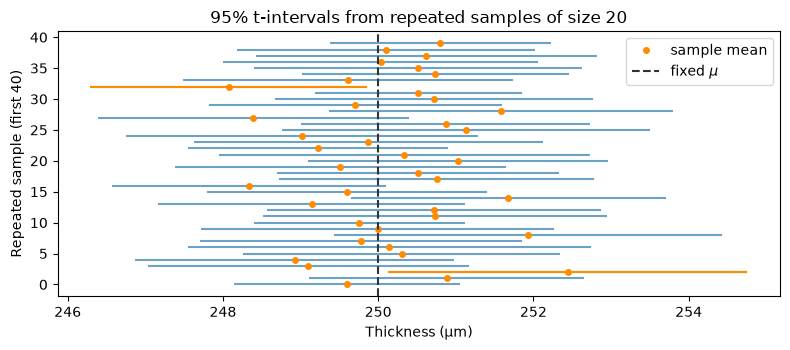

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
show = 40
idx = np.arange(show)
ax.hlines(idx, lo[:show], hi[:show], color="#6CA2C6")
ax.plot(means[:show], idx, "o", color="#FF8C00", ms=4, label=r"sample mean")
ax.axvline(mu_true, color="0.2", linestyle="--", label=r"fixed $\mu$")
miss = ~covers[:show]
ax.hlines(idx[miss], lo[:show][miss], hi[:show][miss], color="#FF8C00")
ax.set_xlabel("Thickness (µm)")
ax.set_ylabel("Repeated sample (first 40)")
ax.set_title("95% t-intervals from repeated samples of size 20")
ax.legend()
plt.tight_layout()
plt.show()


### What changes the width?


In [5]:
def t_halfwidth(n, s, level=0.95):
    return t.ppf((1 + level) / 2, n - 1) * s / np.sqrt(n)

print("current 95% half-width:", t_halfwidth(n, s))
print("if n doubles:         ", t_halfwidth(2 * n, s))
print("if 99% confidence:    ", t_halfwidth(n, s, 0.99))
print("if s is 50% larger:   ", t_halfwidth(n, 1.5 * s))
print("ratio when n doubles: ", t_halfwidth(2 * n, s) / t_halfwidth(n, s))


current 95% half-width: 0.7073470353553151
if n doubles:          0.4984687355127327
if 99% confidence:     0.9332717867827283
if s is 50% larger:    1.0610205530329724
ratio when n doubles:  0.7047018091513475


Doubling $n$ multiplies the half-width by about $1/\sqrt{2}$, not by $1/2$. Extra observations do not correct a biased sensor or a convenience sample.

### Proportion of thick plates: Wilson as the default

Define a thick plate as thickness greater than 255 µm **before** looking at the interval. The parameter is the long-run proportion $p$ under the sampled conditions.


In [6]:
k = int((x > 255).sum())
phat = k / n
wald_se = np.sqrt(phat * (1 - phat) / n)
z = norm.ppf(0.975)
wald = (phat - z * wald_se, phat + z * wald_se)
wilson = proportion_confint(k, n, alpha=0.05, method="wilson")
print(f"k = {k}, n = {n}, phat = {phat:.4f}")
print("Wald 95%  :", tuple(np.round(wald, 4)))
print("Wilson 95%:", tuple(np.round(wilson, 4)))


k = 37, n = 180, phat = 0.2056
Wald 95%  : (np.float64(0.1465), np.float64(0.2646))
Wilson 95%: (np.float64(0.153), np.float64(0.2704))


Wald can fail when counts are small. A compact illustration from the same process: 2 thick plates in a pilot of 20.


In [7]:
k_small, n_small = 2, 20
phat_small = k_small / n_small
wald_small_se = np.sqrt(phat_small * (1 - phat_small) / n_small)
wald_small = (phat_small - z * wald_small_se, phat_small + z * wald_small_se)
wilson_small = proportion_confint(k_small, n_small, alpha=0.05, method="wilson")
print("Wald 95%  :", tuple(np.round(wald_small, 3)))
print("Wilson 95%:", tuple(np.round(wilson_small, 3)))


Wald 95%  : (np.float64(-0.031), np.float64(0.231))
Wilson 95%: (np.float64(0.028), np.float64(0.301))


The Wald lower endpoint can leave $[0,1]$. Wilson stays inside the parameter space. Use Wilson in reports.

### Bootstrap as a computational extension


In [8]:
boot = bootstrap(
    (x,),
    np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    method="percentile",
    random_state=np.random.default_rng(2026),
)
print("bootstrap 95% percentile interval:",
      (boot.confidence_interval.low, boot.confidence_interval.high))
print("t-interval for comparison:        ", (ci_lo, ci_hi))


bootstrap 95% percentile interval: (np.float64(250.13939402777774), np.float64(251.5485597222222))
t-interval for comparison:         (np.float64(250.12300852020027), np.float64(251.53770259091092))


The bootstrap resamples the **observed** plates. It does not repair a biased sample, and it does not replace the $t$ and Wilson procedures as the course defaults.

## 4. Interpretation

The $t$ interval is a statement about $\mu$, the mean thickness in the target process. Individual plates still vary on the scale of $s$, which is much wider than $s/\sqrt n$. A narrow interval for the mean is not a claim that every plate lies in that interval.

The coverage experiment should land near 0.95 when the normal model and independent sampling hold. That number is about the method, not about the one interval from the 180 plates.

## 5. Common mistakes / things to notice

- Interpreting 95% as $P(\mu\in[L,U]\mid\text{this sample})=0.95$.
- Using $z$ because $n$ is large while $\sigma$ remains unknown.
- Reporting the Wald interval as the recommended interval for a proportion.
- Treating a bootstrap interval as new information beyond the sample.
- Confusing a confidence interval for $\mu$ with the spread of individual observations.

**Conclusion:** For these plates report the printed sample mean, the 95% $t$-interval for the **process mean** (not for a single plate), and the Wilson interval for the thick-plate proportion. The 95% refers to long-run coverage of the procedure under the model; extra data narrow the interval only when they are independent observations from the same target population.
